<a href="https://colab.research.google.com/github/narumirr/Visi-Komputer/blob/main/Jobsheet_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Praktikum 02 Klasifikasi Gambar**

*   Andrian Amirudin Rahmanto
*   4.33.25.0.02 / TI-2A

# **Praktikum D1 - Memulai Klasifikasi Gambar dengan Dataset Sederhana**

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


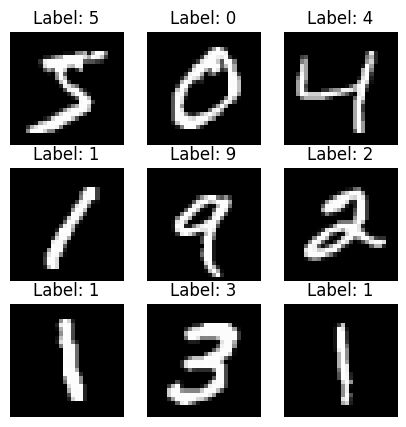

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# Tampilkan contoh
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.show()

Tugas kecil: Cobalah ganti range(9) dengan range(25) untuk menampilkan lebih banyak contoh. Apa yang Anda perhatikan dari bentuk tulisan tangan manusia?

Jawab: Tulisan tangan manusia memiliki variasi yang tinggi seperti:
- Tingkat kemiringan dan ketebalan berbeda beda
- Beberapa angka yang beda bisa terlihat mirip karena distorsi
- Tiap individu punya gaya penulisan yang unik

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


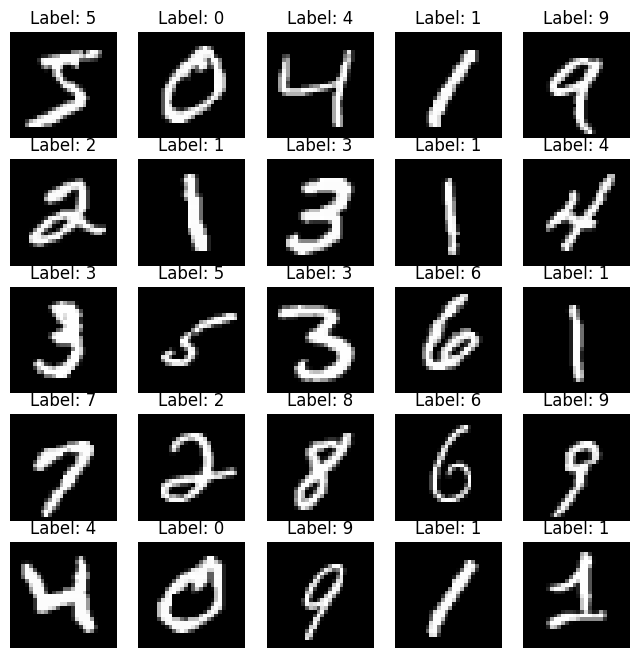

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# Tampilkan contoh
plt.figure(figsize=(8,8))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.show()

# **Praktikum D2 Klasifikasi Gambar dengan Model Machine Learning Tradisional**

In [ ]:
from sklearn import svm
from sklearn.metrics import accuracy_score

# Flatten
x_train_flat = x_train.reshape(len(x_train), -1) / 255.0
x_test_flat = x_test.reshape(len(x_test), -1) / 255.0

# SVM
clf = svm.SVC(kernel='linear', gamma='scale')
clf.fit(x_train_flat[:5000], y_train[:5000]) # gunakan subset karena SVM berat
y_pred = clf.predict(x_test_flat)

print("Akurasi:", accuracy_score(y_test, y_pred))


Akurasi: 0.9101


Tugas kecil: Ubah kernel dari linear menjadi rbf. Bagaimana pengaruhnya terhadap akurasi?

Jawab: Pengaruhnya akurasi menjadi lebih tinggi karena sifat non-linearnya yang mengukur kemiripan antar-gambar berdasarkan jarak Euclidean dan batas keputusan yang fleksibel

In [2]:
from sklearn import svm
from sklearn.metrics import accuracy_score

# Flatten
x_train_flat = x_train.reshape(len(x_train), -1) / 255.0
x_test_flat = x_test.reshape(len(x_test), -1) / 255.0

# SVM
clf = svm.SVC(kernel='rbf', gamma='scale')
clf.fit(x_train_flat[:5000], y_train[:5000]) # gunakan subset karena SVM berat
y_pred = clf.predict(x_test_flat)

print("Akurasi:", accuracy_score(y_test, y_pred))


Akurasi: 0.9513


# **Praktikum D3 - Membangun CNN Sederhana**

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.9481 - loss: 0.1770 - val_accuracy: 0.9812 - val_loss: 0.0686
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9811 - loss: 0.0613 - val_accuracy: 0.9843 - val_loss: 0.0569
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9870 - loss: 0.0413 - val_accuracy: 0.9862 - val_loss: 0.0522
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9912 - loss: 0.0279 - val_accuracy: 0.9880 - val_loss: 0.0505
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9937 - loss: 0.0199 - val_accuracy: 0.9883 - val_loss: 0.0459
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9953 - loss: 0.0145 - val_accuracy: 0.9862 - val_loss: 0.0570
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9963 - loss: 0.0110 - val_accuracy: 0.9873 - val_loss: 0.0599
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9976 - loss: 0.0080 

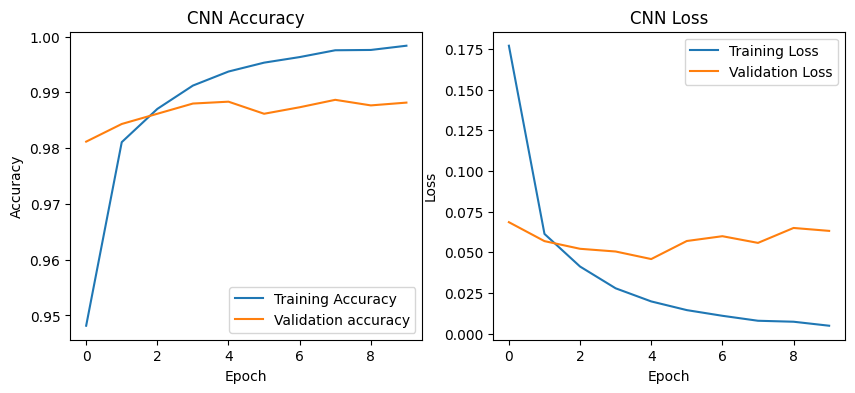

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

x_train_cnn = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test_cnn = x_test.reshape(-1, 28, 28, 1) / 255.0

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu',
input_shape=(28,28,1)), layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train_cnn, y_train, epochs=10,
                    validation_split=0.1)
# ======= Plot history =========
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Tugas kecil: Tambahkan satu lapisan Conv2D lagi sebelum Flatten. Apakah akurasinya meningkat?

Jawab: Pada model 2 layer, val_accuracy sempat mencapai angka 0.9915 (99.15%) pada epoch ke-9, sedangkan pada 1 layer (Gambar 1) akurasi validasi tertahan di kisaran 0.9882 (98.82%). Menambahkan Conv2D kedua berhasil meningkatkan performa terbaik model, tetapi arsitektur yang lebih dalam ini membuat model lebih cepat mengalami overfitting jika dilatih hingga 10 epoch tanpa regulasi.

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.9530 - loss: 0.1549 - val_accuracy: 0.9810 - val_loss: 0.0658
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9838 - loss: 0.0515 - val_accuracy: 0.9853 - val_loss: 0.0477
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9891 - loss: 0.0356 - val_accuracy: 0.9892 - val_loss: 0.0414
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9912 - loss: 0.0272 - val_accuracy: 0.9885 - val_loss: 0.0476
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9937 - loss: 0.0206 - val_accuracy: 0.9905 - val_loss: 0.0350
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9949 - loss: 0.0155 - val_accuracy: 0.9920 - val_loss: 0.0314
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9961 - loss: 0.0118 - val_accuracy: 0.9908 - val_loss: 0.0305
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9967 - loss: 0.0102 -

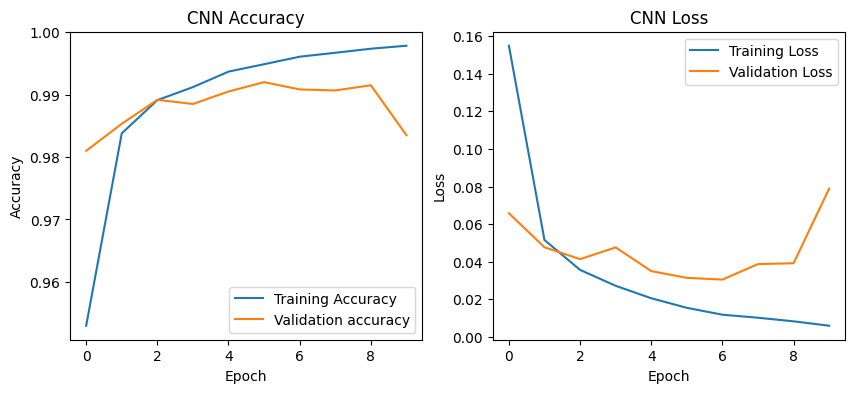

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models

x_train_cnn = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test_cnn = x_test.reshape(-1, 28, 28, 1) / 255.0

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu',
input_shape=(28,28,1)), layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train_cnn, y_train, epochs=10,
                    validation_split=0.1)
# ======= Plot history =========
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# **Praktikum D4 Eksperimen dengan Dataset Lebih Kompleks (CIFAR-10)**

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 18s 0us/step
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.3516 - loss: 2.1072 - val_accuracy: 0.4366 - val_loss: 1.5124
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4798 - loss: 1.4268 - val_accuracy: 0.5410 - val_loss: 1.2883
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5462 - loss: 1.2645 - val_accuracy: 0.5566 - val_loss: 1.2317
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5959 - loss: 1.1442 - val_accuracy: 0.5766 - val_loss: 1.2521
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6314 - loss: 1.0592 - val_accuracy: 0.6168 - val_loss: 1.1136
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6573 - loss: 0.9801 - val_accuracy: 0.6224 - val_loss: 1.1448
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6810 - loss: 0.9134 - val_accuracy: 0.6168 - val_loss: 1.1928
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━

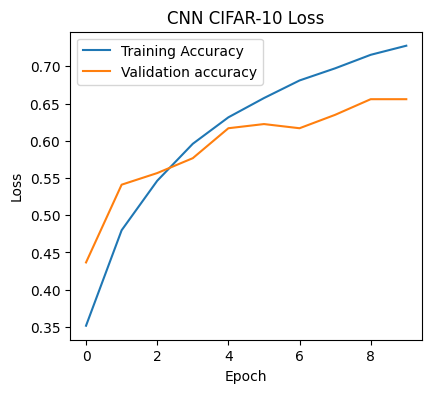

In [ ]:
from tensorflow.keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

model = models.Sequential  ([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, validation_split=0.1)
# === Plot history ===
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('CNN CIFAR-10 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


Tugas kecil: Coba tambahkan Dropout(0.5) sebelum lapisan Dense terakhir. Apa pengaruhnya pada overfitting?

Jawab: Pengaruhnya adalah secara signigikan menekan dan mengurangi overvitting

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.0960 - loss: 2.4514 - val_accuracy: 0.0972 - val_loss: 2.3026
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.0970 - loss: 2.3030 - val_accuracy: 0.0950 - val_loss: 2.3029
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.0984 - loss: 2.3028 - val_accuracy: 0.0970 - val_loss: 2.3029
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.0975 - loss: 2.3028 - val_accuracy: 0.0950 - val_loss: 2.3027
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.0968 - loss: 2.3158 - val_accuracy: 0.0950 - val_loss: 2.3030
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.0992 - loss: 2.3041 - val_accuracy: 0.0958 - val_loss: 2.3031
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.0971 - loss: 2.3028 - val_accuracy: 0.0970 - val_loss: 2.3028
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.0986 - loss: 2.3028 -

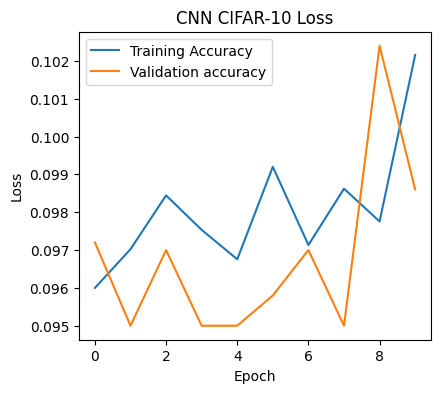

In [5]:
from tensorflow.keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

model = models.Sequential  ([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, validation_split=0.1)
# === Plot history ===
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('CNN CIFAR-10 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


# **Praktikum D5 Transfer Learning dengan Model Pra-Latih**

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.4562 - loss: 2.3667 - val_accuracy: 0.5350 - val_loss: 1.3474
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.5680 - loss: 1.2371 - val_accuracy: 0.5762 - val_loss: 1.2419
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6039 - loss: 1.1352 - val_accuracy: 0.5878 - val_loss: 1.2093
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6230 - loss: 1.0820 - val_accuracy: 0.5930 - val_loss: 1.2281
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6360 - loss: 1.0447 - val_accuracy: 0.5982 - val_loss: 1.2121


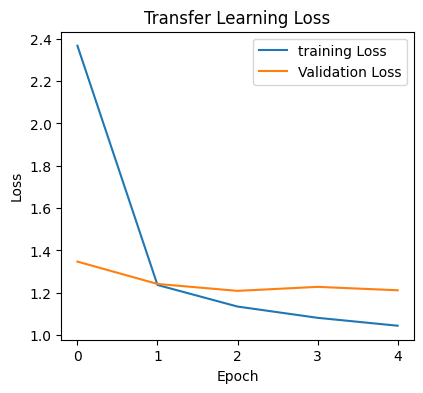

In [ ]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32,32,3))
base_model.trainable = False

model = models.Sequential ([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile (optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=5, validation_split=0.1)
# ====== Plot history =======
plt.figure(figsize=(10,4))
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Transfer Learning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


Tugas kecil: Coba aktifkan 1–2 lapisan terakhir dari base_model (fine-tuning). Bagaimana akurasinya berubah?

Jawab: Akurasinya berubah menjadi menurun, tadinya val accuracy 59 jadi 54

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.3694 - loss: 6.3720 - val_accuracy: 0.4386 - val_loss: 3.7938
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.4903 - loss: 2.8769 - val_accuracy: 0.4800 - val_loss: 2.6752
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.5464 - loss: 2.0239 - val_accuracy: 0.5088 - val_loss: 2.2426
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.5904 - loss: 1.5931 - val_accuracy: 0.5310 - val_loss: 2.0079
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.6310 - loss: 1.3181 - val_accuracy: 0.5480 - val_loss: 1.8606


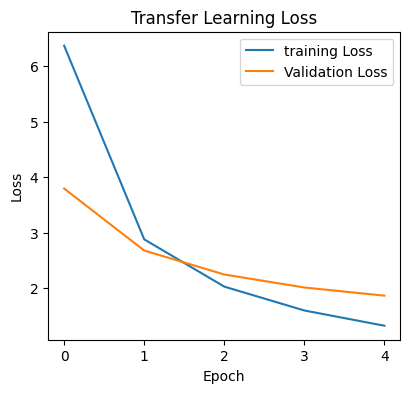

In [9]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32,32,3))
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 2

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model = models.Sequential ([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile (optimizer=Adam(learning_rate=1e-5),
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=5, validation_split=0.1)
# ====== Plot history =======
plt.figure(figsize=(10,4))
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Transfer Learning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


# **Praktikum D6 Evaluasi dengan Confusion Matrix dan Metrix Lain**

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
              precision    recall  f1-score   support

           0       0.63      0.70      0.67      1000
           1       0.69      0.64      0.67      1000
           2       0.53      0.46      0.49      1000
           3       0.42      0.48      0.45      1000
           4       0.48      0.64      0.55      1000
           5       0.64      0.43      0.52      1000
           6       0.62      0.67      0.64      1000
           7       0.65      0.60      0.63      1000
           8       0.71      0.66      0.68      1000
           9       0.63      0.64      0.64      1000

    accuracy                           0.59     10000
   macro avg       0.60      0.59      0.59     10000
weighted avg       0.60      0.59      0.59     10000



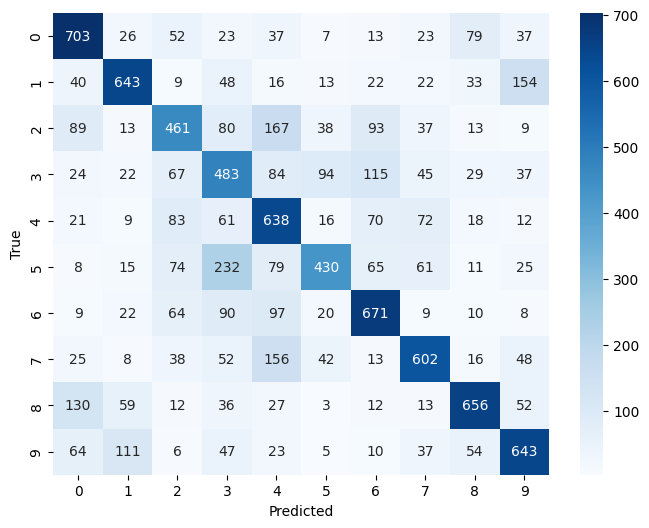

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = model.predict(x_test).argmax(axis=1)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

Tugas kecil: Dari confusion matrix, identifikasi kelas apa yang paling sering salah diklasifikasikan. Menurut Anda, mengapa hal itu bisa terjadi?

Jawab: Kelas yang paling sering salah diklasifikasikan yaitu:

- Kelas 3 (Kucing): Memiliki nilai precision terkecil yaitu 0.42 dan f1-score terendah yaitu 0.45.

- Kelas 5 (Anjing): Memiliki nilai recall terkecil yaitu 0.43 (banyak data anjing yang tidak terdeteksi dengan benar).

- Kelas 2 (Burung): Memiliki recall yang juga sangat rendah yaitu 0.46.

Alasan hal tersebut bisa terjadi yaitu:

- Kemiripan Bentuk: Kucing, anjing, dan burung sama-sama memiliki pola fisik hewan yang sangat mirip (berbulu, berkaki, bentuk telinga samar).

- Detail Kabur: Gambar resolusi rendah ($32 \times 32$ piksel) menghilangkan detail halus yang membedakan wajah antarhewan.

- Kontras dengan Objek: Kendaraan (seperti mobil/kapal) lebih mudah dikenali karena memiliki bentuk geometris yang tegas dibanding hewan.